In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

'18 nov Article with references .gdoc'
'2024-09-24 hiszpanski.gdoc'
'2024 - PODSUMOWANIE (1).pdf'
'2024 - PODSUMOWANIE.pdf'
'2 wyklady - PSYCHOPATOLOGIA .gdoc'
'5 am club.gdoc'
'5 tysiecznik.gdoc'
'6 SLIDES - ADJUSTED .gdoc'
'6 SLIDES.docx'
 ab_test_data.csv
'Accounting .gdoc'
'Activity Template: Impact Report.gslides'
'Activity Template: Project Charter (1).gdoc'
'Activity Template: Project Charter.gdoc'
'Activity Template: Project Plan.gsheet'
'Activity Template: Retrospective Review.gsheet'
'Activity Template: Sauce & Spoon Test Launch Findings.gslides'
'Activity Template: SMART goals.gdoc'
'Activity Template: Stakeholder Analysis.gslides'
 AI.gdoc
'AI_Panel_Briefing rev4.docx'
'AI SUREY'
'AI workshops - Julia Macha.pdf'
'API .gdoc'
 Aplikacja.gsheet
'Aplikacja na studia'
'Aplikacja o prace '
 Arek.gsheet
'Arkusz kalkulacyjny bez tytułu (1).gsheet'
'Arkusz kalkulacyjny bez tytułu (2).gsheet'
'Arkusz kalkulacyjny bez tytułu (3).gsheet'
'Arkusz kalkulacyjny bez tytułu (4).gsheet'
'Ark

In [3]:
!ls /content/drive/MyDrive/msrcorid

 aeroplanes	      flowers
 animals	      kitchen_utensils
 benches_and_chairs   leaves
 bicycles	      miscellaneous
 birds		     'MSR Cambridge EULA for Digital Images.rtf'
 buildings	      scenes
 cars		      signs
 chimneys	      trees
 clouds		      windows
 doors


In [4]:
DATASET_ROOT = "/content/drive/MyDrive/msrcorid"

In [5]:
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict
import random

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".ppm"}

@dataclass(frozen=True)
class ImageItem:
    path: Path
    label: str  # top-level category folder

def build_msrc_index(dataset_root: str) -> List[ImageItem]:
    root = Path(dataset_root).resolve()
    if not root.exists():
        raise FileNotFoundError(f"Dataset root does not exist: {root}")

    top_level_dirs = [p for p in root.iterdir() if p.is_dir()]
    if not top_level_dirs:
        raise RuntimeError(f"No category folders found inside: {root}")

    items: List[ImageItem] = []
    for label_dir in sorted(top_level_dirs):
        label = label_dir.name
        # recursively gather images under this category (handles animals/cows etc.)
        for p in label_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                items.append(ImageItem(path=p, label=label))

    if not items:
        raise RuntimeError(f"No images found under: {root}")
    return items

def summarize_index(items: List[ImageItem]) -> Dict[str, int]:
    counts: Dict[str, int] = {}
    for it in items:
        counts[it.label] = counts.get(it.label, 0) + 1
    return dict(sorted(counts.items()))

# ---- confirmed path ----
DATASET_ROOT = "/content/drive/MyDrive/msrcorid"

items = build_msrc_index(DATASET_ROOT)
counts = summarize_index(items)

print(f"Total images indexed: {len(items)}")
print(f"Total categories: {len(counts)}")
print("Per-category counts:")
for k, v in counts.items():
    print(f"  {k:20s} {v}")

# sanity checks
q = random.choice(items)
rel = [it for it in items if it.label == q.label and it.path != q.path]
print(f"\nExample query: {q.path.name} | label={q.label} | relevant (excluding self) = {len(rel)}")
print("Example image path:", q.path)

Total images indexed: 4323
Total categories: 18
Per-category counts:
  aeroplanes           58
  animals              372
  benches_and_chairs   68
  bicycles             272
  birds                72
  buildings            146
  cars                 505
  chimneys             266
  clouds               429
  doors                166
  flowers              166
  kitchen_utensils     175
  leaves               118
  miscellaneous        188
  scenes               288
  signs                165
  trees                217
  windows              652

Example query: 156_5663.JPG | label=kitchen_utensils | relevant (excluding self) = 174
Example image path: /content/drive/MyDrive/msrcorid/kitchen_utensils/forks/156_5663.JPG


In [6]:
#check what file extensions you actually have
from pathlib import Path
from collections import Counter

DATASET_ROOT = Path("/content/drive/MyDrive/msrcorid")

ext_counts = Counter()
for p in DATASET_ROOT.rglob("*"):
    if p.is_file():
        ext_counts[p.suffix.lower()] += 1

# show top 20 extensions
for ext, cnt in ext_counts.most_common(20):
    print(f"{ext or '<no_ext>' :10s} {cnt}")

.jpg       4323
.rtf       1


In [7]:
#Inspect one folder to see filename patterns
import random
from pathlib import Path

DATASET_ROOT = Path("/content/drive/MyDrive/msrcorid")

cats = [p for p in DATASET_ROOT.iterdir() if p.is_dir()]
print("Top-level category folders found:", len(cats))
print([c.name for c in sorted(cats)])

for cat in random.sample(cats, k=min(5, len(cats))):
    files = [p for p in cat.rglob("*") if p.is_file()]
    print("\n---", cat.name, "---")
    print("Total files:", len(files))
    # show 15 random filenames
    for p in random.sample(files, k=min(15, len(files))):
        print(p.name)

Top-level category folders found: 18
['aeroplanes', 'animals', 'benches_and_chairs', 'bicycles', 'birds', 'buildings', 'cars', 'chimneys', 'clouds', 'doors', 'flowers', 'kitchen_utensils', 'leaves', 'miscellaneous', 'scenes', 'signs', 'trees', 'windows']

--- leaves ---
Total files: 118
109_0969.JPG
109_0992.JPG
113_1317.JPG
109_0989.JPG
159_5999.JPG
119_1941.JPG
113_1387.JPG
113_1310.JPG
127_2760.JPG
161_6163.JPG
113_1316.JPG
119_1943.JPG
109_0986.JPG
113_1390.JPG
113_1382.JPG

--- kitchen_utensils ---
Total files: 175
156_5698.JPG
155_5545.JPG
155_5566.JPG
181_8136.JPG
156_5676.JPG
155_5568.JPG
156_5668.JPG
156_5655.JPG
156_5661.JPG
155_5573.JPG
181_8120.JPG
156_5696.JPG
155_5579.JPG
181_8135.JPG
156_5638.JPG

--- windows ---
Total files: 652
125_2515.JPG
177_7736.JPG
125_2547.JPG
123_2342.JPG
176_7670.JPG
127_2778.JPG
125_2530.JPG
177_7762.JPG
123_2350.JPG
127_2782.JPG
121_2190.JPG
123_2303.JPG
122_2208.JPG
128_2806.JPG
122_2223.JPG

--- benches_and_chairs ---
Total files: 68
183_83

In [8]:
!find /content/drive/MyDrive/msrcorid -maxdepth 3 -type d | head -n 200

/content/drive/MyDrive/msrcorid
/content/drive/MyDrive/msrcorid/scenes
/content/drive/MyDrive/msrcorid/scenes/office
/content/drive/MyDrive/msrcorid/scenes/countryside
/content/drive/MyDrive/msrcorid/scenes/urban
/content/drive/MyDrive/msrcorid/windows
/content/drive/MyDrive/msrcorid/kitchen_utensils
/content/drive/MyDrive/msrcorid/kitchen_utensils/knives
/content/drive/MyDrive/msrcorid/kitchen_utensils/spoons
/content/drive/MyDrive/msrcorid/kitchen_utensils/forks
/content/drive/MyDrive/msrcorid/trees
/content/drive/MyDrive/msrcorid/trees/single
/content/drive/MyDrive/msrcorid/trees/general
/content/drive/MyDrive/msrcorid/miscellaneous
/content/drive/MyDrive/msrcorid/leaves
/content/drive/MyDrive/msrcorid/signs
/content/drive/MyDrive/msrcorid/doors
/content/drive/MyDrive/msrcorid/flowers
/content/drive/MyDrive/msrcorid/flowers/general
/content/drive/MyDrive/msrcorid/flowers/single
/content/drive/MyDrive/msrcorid/clouds
/content/drive/MyDrive/msrcorid/cars
/content/drive/MyDrive/msrcori

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple
import random

print("Num indexed items:", len(items))
print("Example:", items[0])

Num indexed items: 4323
Example: ImageItem(path=PosixPath('/content/drive/MyDrive/msrcorid/aeroplanes/single/166_6623.JPG'), label='aeroplanes')


In [10]:
def load_image_rgb(path: Path, size: Tuple[int, int]=(256, 256)) -> np.ndarray:
    """
    Load an image, convert to RGB, resize, return uint8 array (H,W,3).
    """
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize(size, Image.BILINEAR)
    return np.array(img, dtype=np.uint8)

def rgb_hist_feature(img_rgb: np.ndarray, bins_per_channel: int = 8) -> np.ndarray:
    """
    Global RGB histogram feature.
    - bins_per_channel=8 -> 8*8*8 = 512 dims
    Returns L1-normalized float32 vector.
    """
    assert img_rgb.ndim == 3 and img_rgb.shape[2] == 3
    # Compute 3D histogram over RGB
    hist, _ = np.histogramdd(
        img_rgb.reshape(-1, 3),
        bins=(bins_per_channel, bins_per_channel, bins_per_channel),
        range=((0, 256), (0, 256), (0, 256))
    )
    feat = hist.astype(np.float32).ravel()
    s = feat.sum()
    if s > 0:
        feat /= s  # L1 normalize
    return feat

In [11]:
def build_feature_matrix(items, bins_per_channel=8, size=(256,256), max_items=None):
    """
    Compute features for all items (or first max_items for quick testing).
    """
    if max_items is not None:
        items_use = items[:max_items]
    else:
        items_use = items

    X = []
    paths = []
    labels = []

    for i, it in enumerate(items_use):
        img = load_image_rgb(it.path, size=size)
        feat = rgb_hist_feature(img, bins_per_channel=bins_per_channel)
        X.append(feat)
        paths.append(it.path)
        labels.append(it.label)

        if (i+1) % 500 == 0:
            print(f"Processed {i+1}/{len(items_use)}")

    X = np.vstack(X)  # (N,D)
    return X, paths, labels


X, paths, labels = build_feature_matrix(items, bins_per_channel=8, size=(256,256), max_items=None)

print("Feature matrix shape:", X.shape)

Processed 500/4323
Processed 1000/4323
Processed 1500/4323
Processed 2000/4323
Processed 2500/4323
Processed 3000/4323
Processed 3500/4323
Processed 4000/4323
Feature matrix shape: (4323, 512)


In [12]:
def rank_by_euclidean(query_feat: np.ndarray, X: np.ndarray) -> np.ndarray:
    """
    Returns indices sorted by increasing Euclidean distance.
    """
    # (N,D) - (D,) -> (N,D)
    dists = np.linalg.norm(X - query_feat[None, :], axis=1)
    return np.argsort(dists), dists

def retrieve_topk(query_index: int, X: np.ndarray, paths: List[Path], labels: List[str], k: int = 10):
    """
    Retrieve top-k results for a query image at query_index.
    Excludes self-match.
    """
    q_feat = X[query_index]
    order, dists = rank_by_euclidean(q_feat, X)

    # remove self index
    order = [idx for idx in order if idx != query_index]
    topk = order[:k]
    return topk, dists

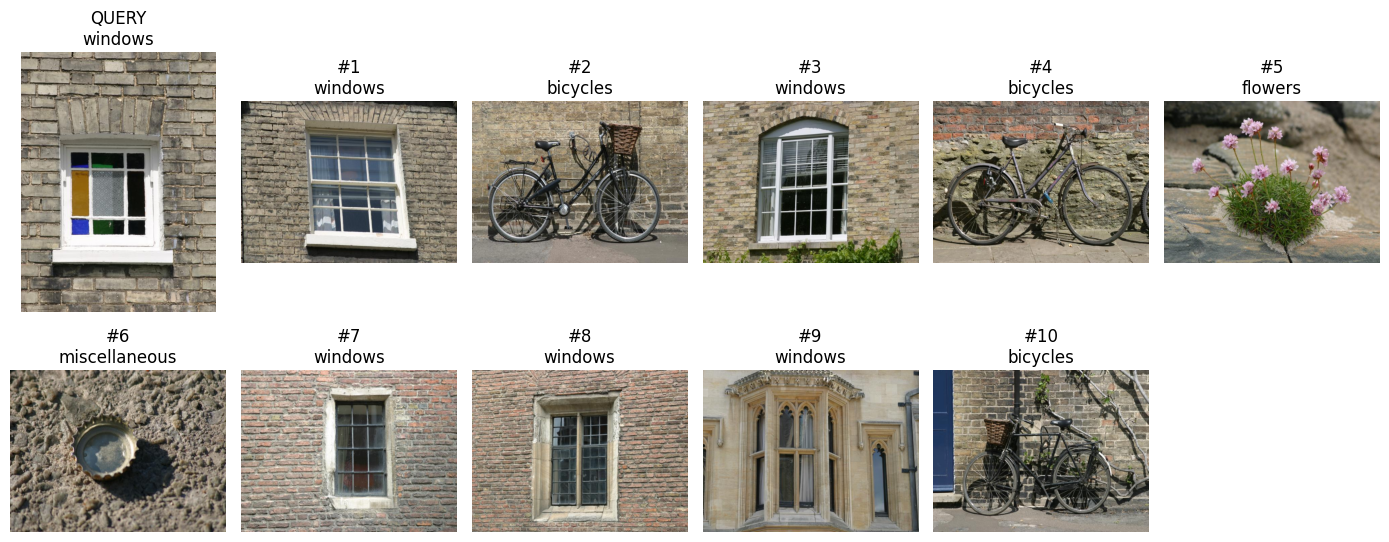

In [13]:
def show_retrieval(query_index: int, topk_indices: List[int], paths: List[Path], labels: List[str], k: int = 10):
    """
    Show query and top-k retrieved images in a grid.
    """
    cols = 6
    rows = 2  # query + first 10 fits well with 2 rows of 6 (12 slots)

    plt.figure(figsize=(14, 6))

    # Query
    q_img = Image.open(paths[query_index]).convert("RGB")
    plt.subplot(rows, cols, 1)
    plt.imshow(q_img)
    plt.axis("off")
    plt.title(f"QUERY\n{labels[query_index]}")

    # Retrieved
    for j, idx in enumerate(topk_indices[:k]):
        img = Image.open(paths[idx]).convert("RGB")
        plt.subplot(rows, cols, j+2)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"#{j+1}\n{labels[idx]}")

    plt.tight_layout()
    plt.show()

# A random query
query_index = random.randrange(len(paths))
topk, dists = retrieve_topk(query_index, X, paths, labels, k=10)
show_retrieval(query_index, topk, paths, labels, k=10)

In [14]:
import numpy as np

def euclidean_distance_matrix(X: np.ndarray, q: np.ndarray) -> np.ndarray:
    # Euclidean distance to all rows of X
    return np.linalg.norm(X - q[None, :], axis=1)

def cosine_distance_matrix(X: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    # 1 - cosine similarity
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
    qn = q / (np.linalg.norm(q) + eps)
    cos_sim = Xn @ qn
    return 1.0 - cos_sim

def chi_square_distance_matrix(X: np.ndarray, q: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    # Chi-square distance for histograms: 0.5 * sum((xi-qi)^2/(xi+qi+eps))
    num = (X - q[None, :]) ** 2
    den = (X + q[None, :] + eps)
    return 0.5 * np.sum(num / den, axis=1)

def retrieve_topk_metric(query_index: int, X: np.ndarray, paths, labels, k: int = 10, metric: str = "euclidean"):
    q = X[query_index]

    if metric == "euclidean":
        d = euclidean_distance_matrix(X, q)
    elif metric == "cosine":
        d = cosine_distance_matrix(X, q)
    elif metric == "chi2":
        d = chi_square_distance_matrix(X, q)
    else:
        raise ValueError("metric must be one of: 'euclidean', 'cosine', 'chi2'")

    order = np.argsort(d)
    order = [idx for idx in order if idx != query_index]  # exclude self
    return order[:k], d

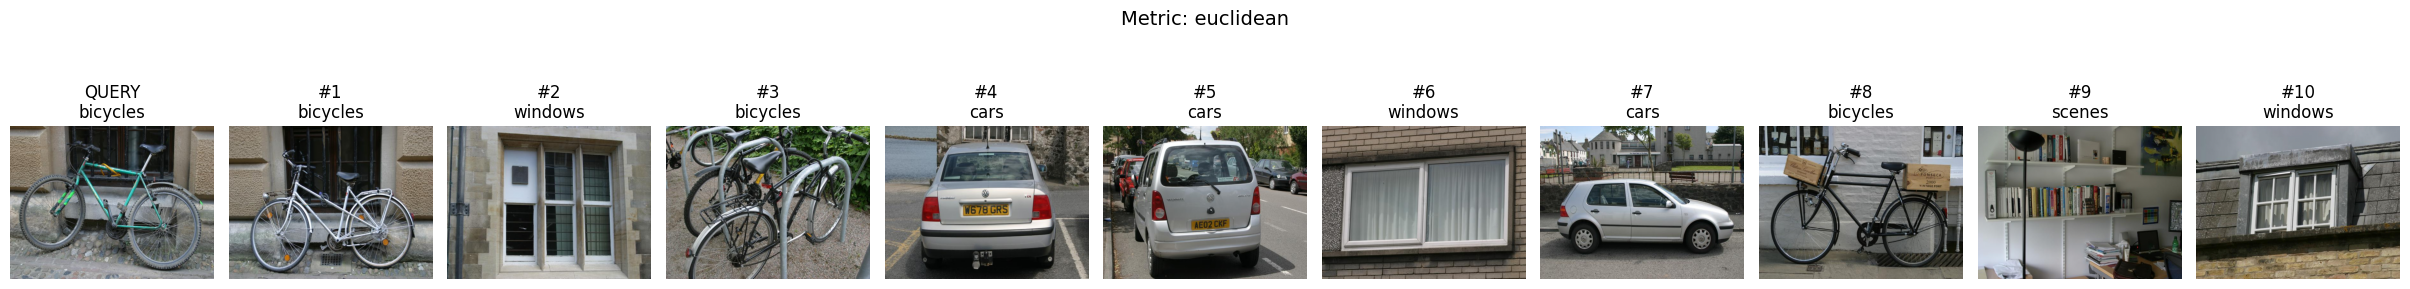

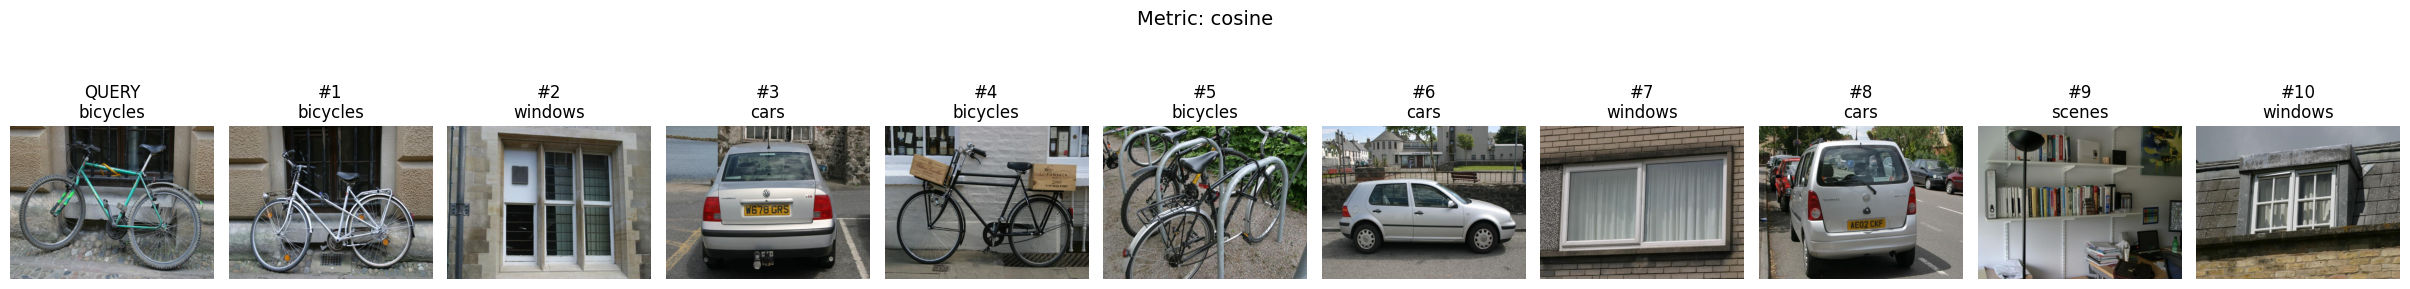

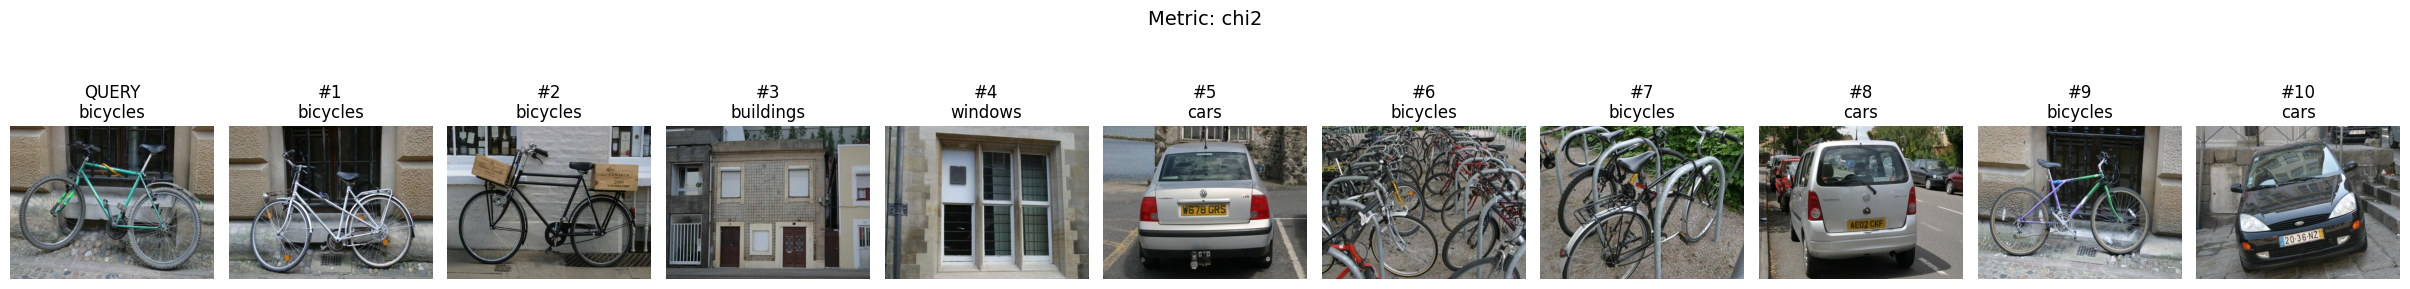

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_retrieval_row(query_index, topk_indices, title, paths, labels, k=10):
    cols = k + 1
    plt.figure(figsize=(2.2*cols, 3.2))

    # Query
    q_img = Image.open(paths[query_index]).convert("RGB")
    plt.subplot(1, cols, 1)
    plt.imshow(q_img)
    plt.axis("off")
    plt.title(f"QUERY\n{labels[query_index]}")

    for j, idx in enumerate(topk_indices[:k]):
        img = Image.open(paths[idx]).convert("RGB")
        plt.subplot(1, cols, j+2)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"#{j+1}\n{labels[idx]}")

    plt.suptitle(title, y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

# Pick a random query (or set query_index manually)
query_index = random.randrange(len(paths))

for metric in ["euclidean", "cosine", "chi2"]:
    topk, d = retrieve_topk_metric(query_index, X, paths, labels, k=10, metric=metric)
    show_retrieval_row(query_index, topk, f"Metric: {metric}", paths, labels, k=10)

In [16]:
import numpy as np
from collections import defaultdict

# Build label -> indices for fast relevance lookup
label_to_indices = defaultdict(list)
for idx, lab in enumerate(labels):
    label_to_indices[lab].append(idx)

def average_precision_from_ranks(relevant_flags: np.ndarray) -> float:
    """
    relevant_flags: boolean array of length R (ranked list), True if relevant at that rank.
    AP = mean precision at ranks where relevant == True
    """
    rel_positions = np.where(relevant_flags)[0]
    if len(rel_positions) == 0:
        return 0.0
    precisions = []
    hits = 0
    for r in range(len(relevant_flags)):
        if relevant_flags[r]:
            hits += 1
            precisions.append(hits / (r + 1))
    return float(np.mean(precisions))

def map_for_metric(X: np.ndarray, labels: list, metric: str = "chi2", max_queries: int = None) -> dict:
    """
    Computes:
    - overall mAP
    - per-class mean AP
    Uses leave-one-out: query is excluded from ranking.
    """
    N = X.shape[0]
    query_indices = list(range(N))
    if max_queries is not None:
        query_indices = query_indices[:max_queries]  # for quick testing

    ap_list = []
    ap_by_class = defaultdict(list)

    for qi_i, qi in enumerate(query_indices):
        qlab = labels[qi]
        relevant_set = set(label_to_indices[qlab])
        relevant_set.discard(qi)  # exclude self

        # distances to all
        if metric == "euclidean":
            d = euclidean_distance_matrix(X, X[qi])
        elif metric == "cosine":
            d = cosine_distance_matrix(X, X[qi])
        elif metric == "chi2":
            d = chi_square_distance_matrix(X, X[qi])
        else:
            raise ValueError("metric must be one of: 'euclidean', 'cosine', 'chi2'")

        order = np.argsort(d)
        order = order[order != qi]  # remove self from ranking

        # relevance flags over the full ranked list
        relevant_flags = np.array([idx in relevant_set for idx in order], dtype=bool)

        ap = average_precision_from_ranks(relevant_flags)
        ap_list.append(ap)
        ap_by_class[qlab].append(ap)

        if (qi_i + 1) % 200 == 0:
            print(f"Processed {qi_i+1}/{len(query_indices)} queries")

    mean_ap = float(np.mean(ap_list))
    per_class_map = {c: float(np.mean(v)) for c, v in ap_by_class.items()}
    return {"mAP": mean_ap, "per_class_AP": per_class_map}

# Quick test first: compute on first 300 queries
# results = map_for_metric(X, labels, metric="chi2", max_queries=300)

results = map_for_metric(X, labels, metric="chi2", max_queries=None)
print("\nOverall mAP (chi2):", results["mAP"])

# Show best/worst 5 classes by AP
per_class = results["per_class_AP"]
best5 = sorted(per_class.items(), key=lambda kv: kv[1], reverse=True)[:5]
worst5 = sorted(per_class.items(), key=lambda kv: kv[1])[:5]

print("\nTop 5 classes by AP:")
for c, v in best5:
    print(f"  {c:20s} {v:.3f}")

print("\nBottom 5 classes by AP:")
for c, v in worst5:
    print(f"  {c:20s} {v:.3f}")

Processed 200/4323 queries
Processed 400/4323 queries
Processed 600/4323 queries
Processed 800/4323 queries
Processed 1000/4323 queries
Processed 1200/4323 queries
Processed 1400/4323 queries
Processed 1600/4323 queries
Processed 1800/4323 queries
Processed 2000/4323 queries
Processed 2200/4323 queries
Processed 2400/4323 queries
Processed 2600/4323 queries
Processed 2800/4323 queries
Processed 3000/4323 queries
Processed 3200/4323 queries
Processed 3400/4323 queries
Processed 3600/4323 queries
Processed 3800/4323 queries
Processed 4000/4323 queries
Processed 4200/4323 queries

Overall mAP (chi2): 0.2773786065668997

Top 5 classes by AP:
  clouds               0.559
  cars                 0.421
  chimneys             0.371
  windows              0.355
  animals              0.312

Bottom 5 classes by AP:
  signs                0.041
  benches_and_chairs   0.045
  birds                0.048
  miscellaneous        0.052
  buildings            0.067


PR: processed 200/4323
PR: processed 400/4323
PR: processed 600/4323
PR: processed 800/4323
PR: processed 1000/4323
PR: processed 1200/4323
PR: processed 1400/4323
PR: processed 1600/4323
PR: processed 1800/4323
PR: processed 2000/4323
PR: processed 2200/4323
PR: processed 2400/4323
PR: processed 2600/4323
PR: processed 2800/4323
PR: processed 3000/4323
PR: processed 3200/4323
PR: processed 3400/4323
PR: processed 3600/4323
PR: processed 3800/4323
PR: processed 4000/4323
PR: processed 4200/4323


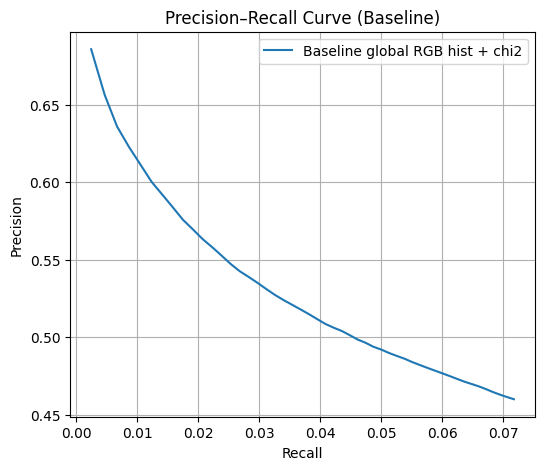

In [27]:
recall_k, precision_k = pr_curve_micro(
    X,
    labels,
    metric="chi2",
    max_k=50,
    max_queries=None
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(recall_k, precision_k, label="Baseline global RGB hist + chi2")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Baseline)")
plt.grid(True)
plt.legend()
plt.show()

CM: processed 200/4323
CM: processed 400/4323
CM: processed 600/4323
CM: processed 800/4323
CM: processed 1000/4323
CM: processed 1200/4323
CM: processed 1400/4323
CM: processed 1600/4323
CM: processed 1800/4323
CM: processed 2000/4323
CM: processed 2200/4323
CM: processed 2400/4323
CM: processed 2600/4323
CM: processed 2800/4323
CM: processed 3000/4323
CM: processed 3200/4323
CM: processed 3400/4323
CM: processed 3600/4323
CM: processed 3800/4323
CM: processed 4000/4323
CM: processed 4200/4323


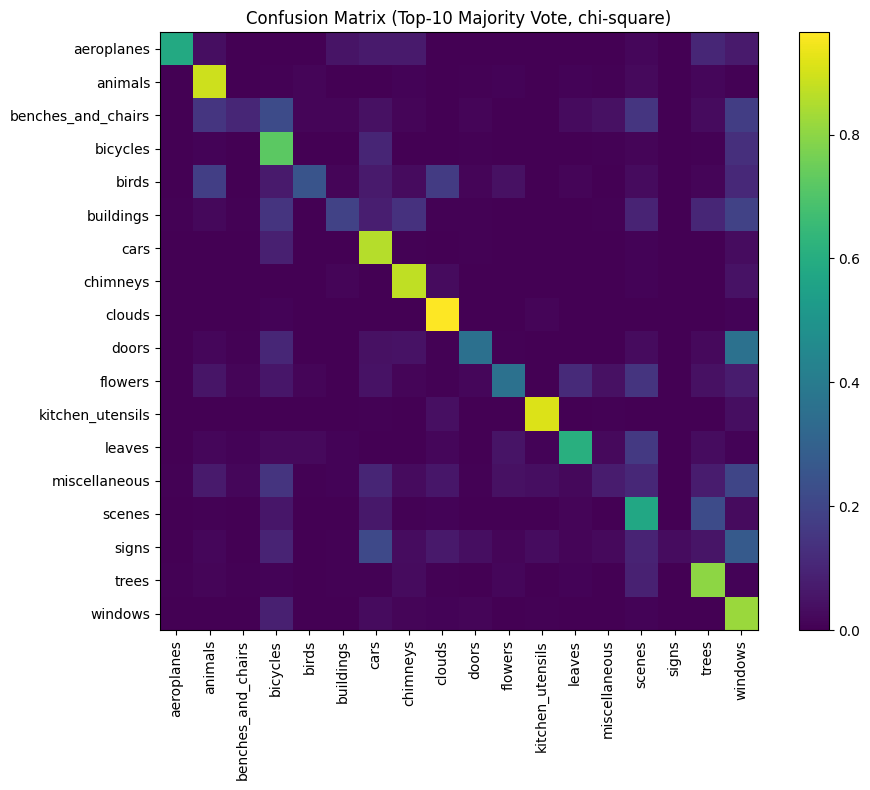


Top 10 confusions (rate, true -> predicted, count):
0.361  doors                -> windows               (60)
0.273  signs                -> windows               (45)
0.221  benches_and_chairs   -> bicycles              (15)
0.219  scenes               -> trees                 (63)
0.212  signs                -> cars                  (35)
0.202  miscellaneous        -> windows               (38)
0.192  buildings            -> windows               (28)
0.181  birds                -> animals               (13)
0.176  benches_and_chairs   -> windows               (12)
0.167  birds                -> clouds                (12)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def confusion_matrix_topk(X: np.ndarray, labels: list, metric: str = "chi2", k: int = 10, max_queries: int = None):
    classes = sorted(set(labels))
    cls_to_id = {c:i for i,c in enumerate(classes)}
    C = np.zeros((len(classes), len(classes)), dtype=np.int64)

    N = X.shape[0]
    query_indices = list(range(N))
    if max_queries is not None:
        query_indices = query_indices[:max_queries]

    for qi_i, qi in enumerate(query_indices):
        true_lab = labels[qi]

        # compute distances
        if metric == "euclidean":
            d = euclidean_distance_matrix(X, X[qi])
        elif metric == "cosine":
            d = cosine_distance_matrix(X, X[qi])
        elif metric == "chi2":
            d = chi_square_distance_matrix(X, X[qi])
        else:
            raise ValueError("metric must be one of: 'euclidean', 'cosine', 'chi2'")

        order = np.argsort(d)
        order = order[order != qi]
        topk = order[:k]

        pred_lab = Counter([labels[idx] for idx in topk]).most_common(1)[0][0]
        C[cls_to_id[true_lab], cls_to_id[pred_lab]] += 1

        if (qi_i + 1) % 200 == 0:
            print(f"CM: processed {qi_i+1}/{len(query_indices)}")

    return C, classes

C, classes = confusion_matrix_topk(X, labels, metric="chi2", k=10, max_queries=None)

# Normalize rows to percentages for easier interpretation
C_norm = C / C.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(C_norm, interpolation="nearest")
plt.title("Confusion Matrix (Top-10 Majority Vote, chi-square)")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.tight_layout()
plt.show()

# Show top confusions (off-diagonal)
confusions = []
for i, true_c in enumerate(classes):
    for j, pred_c in enumerate(classes):
        if i != j:
            confusions.append((C_norm[i, j], true_c, pred_c, C[i, j]))
confusions.sort(reverse=True)

print("\nTop 10 confusions (rate, true -> predicted, count):")
for rate, t, p, cnt in confusions[:10]:
    print(f"{rate:.3f}  {t:20s} -> {p:20s}  ({cnt})")

In [18]:
import numpy as np

def spatial_rgb_hist_feature(img_rgb: np.ndarray, bins_per_channel: int = 8, grid: int = 2) -> np.ndarray:
    """
    Spatial RGB histogram: split into grid x grid regions (default 2x2),
    compute rgb_hist_feature per region, concatenate, then L1-normalize.
    """
    H, W, _ = img_rgb.shape
    feats = []

    # region boundaries
    ys = np.linspace(0, H, grid + 1, dtype=int)
    xs = np.linspace(0, W, grid + 1, dtype=int)

    for gy in range(grid):
        for gx in range(grid):
            y0, y1 = ys[gy], ys[gy+1]
            x0, x1 = xs[gx], xs[gx+1]
            region = img_rgb[y0:y1, x0:x1, :]
            feats.append(rgb_hist_feature(region, bins_per_channel=bins_per_channel))

    feat = np.concatenate(feats).astype(np.float32)

    # global L1 normalization
    s = feat.sum()
    if s > 0:
        feat /= s
    return feat

In [19]:
def build_spatial_feature_matrix(items, bins_per_channel=8, size=(256,256), grid=2, max_items=None):
    if max_items is not None:
        items_use = items[:max_items]
    else:
        items_use = items

    X = []
    paths_sp = []
    labels_sp = []

    for i, it in enumerate(items_use):
        img = load_image_rgb(it.path, size=size)
        feat = spatial_rgb_hist_feature(img, bins_per_channel=bins_per_channel, grid=grid)
        X.append(feat)
        paths_sp.append(it.path)
        labels_sp.append(it.label)

        if (i+1) % 500 == 0:
            print(f"Processed {i+1}/{len(items_use)}")

    X = np.vstack(X)
    return X, paths_sp, labels_sp

X_sp, paths_sp, labels_sp = build_spatial_feature_matrix(items, bins_per_channel=8, size=(256,256), grid=2, max_items=None)
print("Spatial feature matrix shape:", X_sp.shape)

Processed 500/4323
Processed 1000/4323
Processed 1500/4323
Processed 2000/4323
Processed 2500/4323
Processed 3000/4323
Processed 3500/4323
Processed 4000/4323
Spatial feature matrix shape: (4323, 2048)


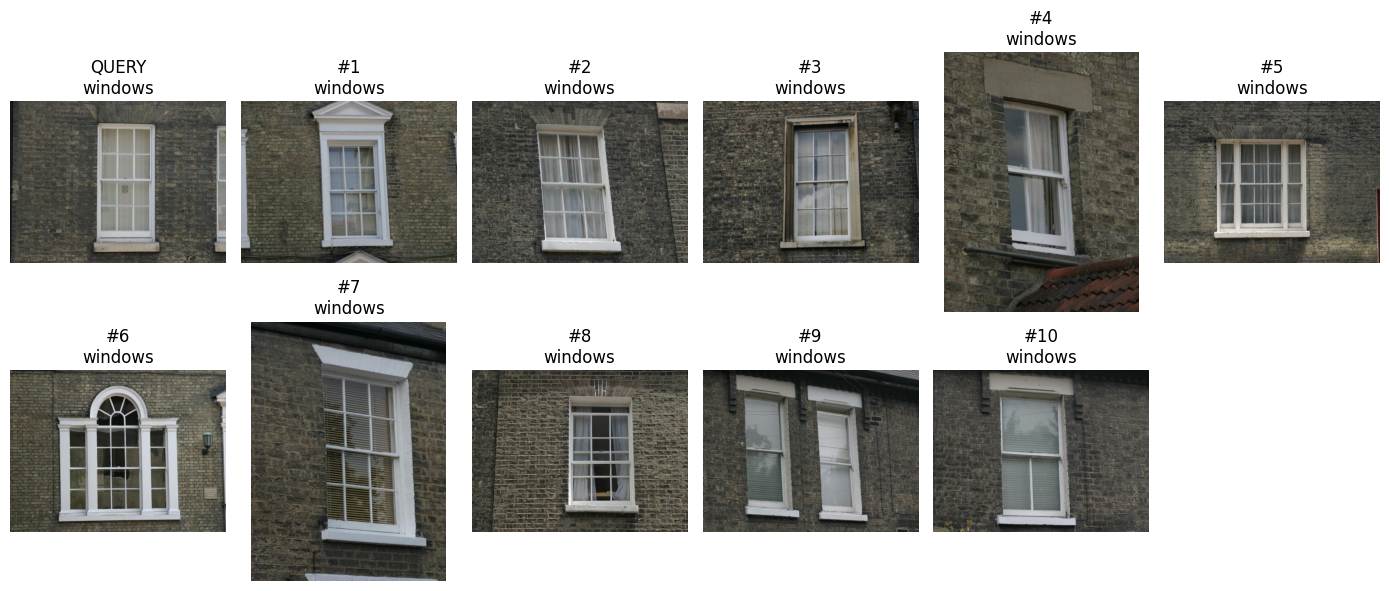

In [20]:
# Use chi-square with spatial features
query_index = random.randrange(len(paths_sp))
topk_sp, _ = retrieve_topk_metric(query_index, X_sp, paths_sp, labels_sp, k=10, metric="chi2")
show_retrieval(query_index, topk_sp, paths_sp, labels_sp, k=10)

In [21]:
# Rebuild label_to_indices for labels_sp
from collections import defaultdict

label_to_indices_sp = defaultdict(list)
for idx, lab in enumerate(labels_sp):
    label_to_indices_sp[lab].append(idx)

def map_for_metric_with_label_index(X: np.ndarray, labels: list, label_to_indices: dict, metric: str = "chi2", max_queries: int = None) -> dict:
    N = X.shape[0]
    query_indices = list(range(N))
    if max_queries is not None:
        query_indices = query_indices[:max_queries]

    ap_list = []
    ap_by_class = defaultdict(list)

    for qi_i, qi in enumerate(query_indices):
        qlab = labels[qi]
        relevant_set = set(label_to_indices[qlab])
        relevant_set.discard(qi)

        if metric == "euclidean":
            d = euclidean_distance_matrix(X, X[qi])
        elif metric == "cosine":
            d = cosine_distance_matrix(X, X[qi])
        elif metric == "chi2":
            d = chi_square_distance_matrix(X, X[qi])
        else:
            raise ValueError("metric must be one of: 'euclidean', 'cosine', 'chi2'")

        order = np.argsort(d)
        order = order[order != qi]

        relevant_flags = np.array([idx in relevant_set for idx in order], dtype=bool)
        ap = average_precision_from_ranks(relevant_flags)

        ap_list.append(ap)
        ap_by_class[qlab].append(ap)

        if (qi_i + 1) % 200 == 0:
            print(f"Processed {qi_i+1}/{len(query_indices)} queries")

    mean_ap = float(np.mean(ap_list))
    per_class_map = {c: float(np.mean(v)) for c, v in ap_by_class.items()}
    return {"mAP": mean_ap, "per_class_AP": per_class_map}

results_sp = map_for_metric_with_label_index(X_sp, labels_sp, label_to_indices_sp, metric="chi2", max_queries=None)

print("\nOverall mAP (spatial 2x2, chi2):", results_sp["mAP"])

per_class_sp = results_sp["per_class_AP"]
best5_sp = sorted(per_class_sp.items(), key=lambda kv: kv[1], reverse=True)[:5]
worst5_sp = sorted(per_class_sp.items(), key=lambda kv: kv[1])[:5]

print("\nTop 5 classes by AP (spatial):")
for c, v in best5_sp:
    print(f"  {c:20s} {v:.3f}")

print("\nBottom 5 classes by AP (spatial):")
for c, v in worst5_sp:
    print(f"  {c:20s} {v:.3f}")

Processed 200/4323 queries
Processed 400/4323 queries
Processed 600/4323 queries
Processed 800/4323 queries
Processed 1000/4323 queries
Processed 1200/4323 queries
Processed 1400/4323 queries
Processed 1600/4323 queries
Processed 1800/4323 queries
Processed 2000/4323 queries
Processed 2200/4323 queries
Processed 2400/4323 queries
Processed 2600/4323 queries
Processed 2800/4323 queries
Processed 3000/4323 queries
Processed 3200/4323 queries
Processed 3400/4323 queries
Processed 3600/4323 queries
Processed 3800/4323 queries
Processed 4000/4323 queries
Processed 4200/4323 queries

Overall mAP (spatial 2x2, chi2): 0.29202840110410794

Top 5 classes by AP (spatial):
  clouds               0.531
  cars                 0.432
  windows              0.417
  chimneys             0.397
  trees                0.337

Bottom 5 classes by AP (spatial):
  signs                0.043
  benches_and_chairs   0.045
  birds                0.051
  miscellaneous        0.051
  buildings            0.069


In [22]:
import numpy as np

def pr_curve_micro(X: np.ndarray, labels: list, metric: str = "chi2", max_k: int = 50, max_queries: int = None):
    N = X.shape[0]
    query_indices = list(range(N))
    if max_queries is not None:
        query_indices = query_indices[:max_queries]

    precisions_at_k = np.zeros(max_k, dtype=np.float64)
    recalls_at_k = np.zeros(max_k, dtype=np.float64)

    for qi_i, qi in enumerate(query_indices):
        qlab = labels[qi]
        relevant_set = set(label_to_indices_sp[qlab] if labels is labels_sp else label_to_indices[qlab])
        relevant_set.discard(qi)
        n_relevant = len(relevant_set)
        if n_relevant == 0:
            continue

        if metric == "euclidean":
            d = euclidean_distance_matrix(X, X[qi])
        elif metric == "cosine":
            d = cosine_distance_matrix(X, X[qi])
        elif metric == "chi2":
            d = chi_square_distance_matrix(X, X[qi])
        else:
            raise ValueError("metric must be one of: 'euclidean', 'cosine', 'chi2'")

        order = np.argsort(d)
        order = order[order != qi]

        hits = 0
        for k in range(1, max_k + 1):
            if order[k-1] in relevant_set:
                hits += 1
            precisions_at_k[k-1] += hits / k
            recalls_at_k[k-1] += hits / n_relevant

        if (qi_i + 1) % 200 == 0:
            print(f"PR: processed {qi_i+1}/{len(query_indices)}")

    Q = len(query_indices)
    precisions_at_k /= Q
    recalls_at_k /= Q
    return recalls_at_k, precisions_at_k

CM: processed 200/4323
CM: processed 400/4323
CM: processed 600/4323
CM: processed 800/4323
CM: processed 1000/4323
CM: processed 1200/4323
CM: processed 1400/4323
CM: processed 1600/4323
CM: processed 1800/4323
CM: processed 2000/4323
CM: processed 2200/4323
CM: processed 2400/4323
CM: processed 2600/4323
CM: processed 2800/4323
CM: processed 3000/4323
CM: processed 3200/4323
CM: processed 3400/4323
CM: processed 3600/4323
CM: processed 3800/4323
CM: processed 4000/4323
CM: processed 4200/4323


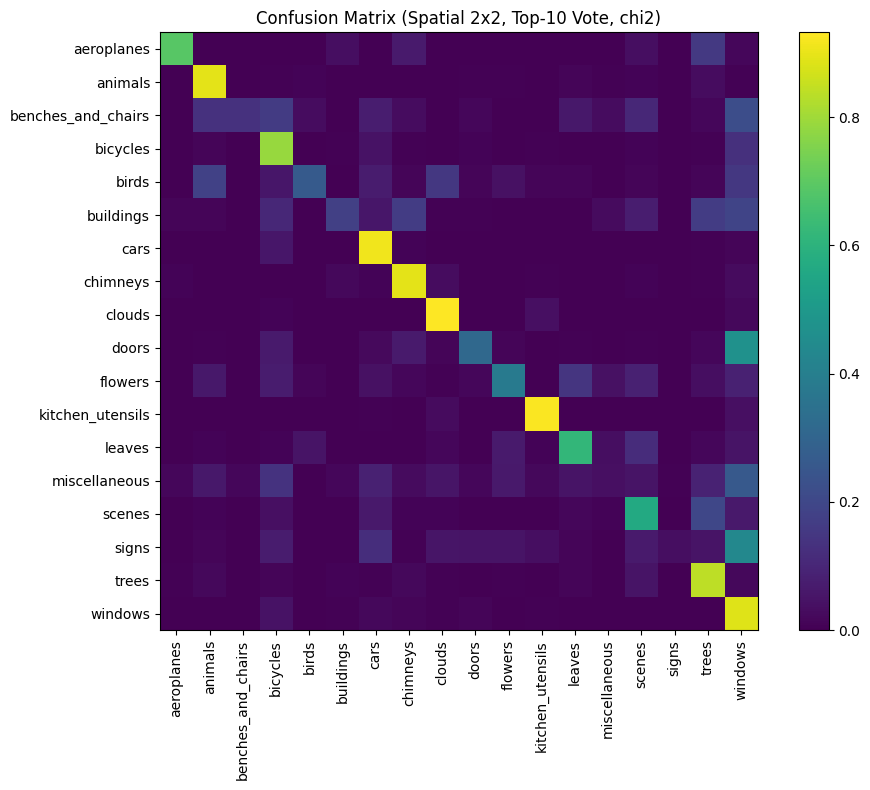


Top 10 confusions (spatial) (rate, true -> predicted, count):
0.470  doors                -> windows               (78)
0.436  signs                -> windows               (72)
0.261  miscellaneous        -> windows               (49)
0.221  benches_and_chairs   -> windows               (15)
0.198  scenes               -> trees                 (57)
0.192  buildings            -> windows               (28)
0.181  birds                -> animals               (13)
0.164  buildings            -> trees                 (24)
0.164  buildings            -> chimneys              (24)
0.162  benches_and_chairs   -> bicycles              (11)


In [23]:
C_sp, classes_sp = confusion_matrix_topk(X_sp, labels_sp, metric="chi2", k=10, max_queries=None)
C_sp_norm = C_sp / C_sp.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(C_sp_norm, interpolation="nearest")
plt.title("Confusion Matrix (Spatial 2x2, Top-10 Vote, chi2)")
plt.colorbar()
plt.xticks(range(len(classes_sp)), classes_sp, rotation=90)
plt.yticks(range(len(classes_sp)), classes_sp)
plt.tight_layout()
plt.show()

# Top confusions (off-diagonal)
confusions_sp = []
for i, true_c in enumerate(classes_sp):
    for j, pred_c in enumerate(classes_sp):
        if i != j:
            confusions_sp.append((C_sp_norm[i, j], true_c, pred_c, C_sp[i, j]))
confusions_sp.sort(reverse=True)

print("\nTop 10 confusions (spatial) (rate, true -> predicted, count):")
for rate, t, p, cnt in confusions_sp[:10]:
    print(f"{rate:.3f}  {t:20s} -> {p:20s}  ({cnt})")

In [24]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=0.95, svd_solver="full", random_state=0)

X_sp_pca = pca.fit_transform(X_sp)

print("Original dim:", X_sp.shape[1])
print("PCA dim:", X_sp_pca.shape[1])
print("Explained variance ratio (sum):", pca.explained_variance_ratio_.sum())

Original dim: 2048
PCA dim: 137
Explained variance ratio (sum): 0.95005804


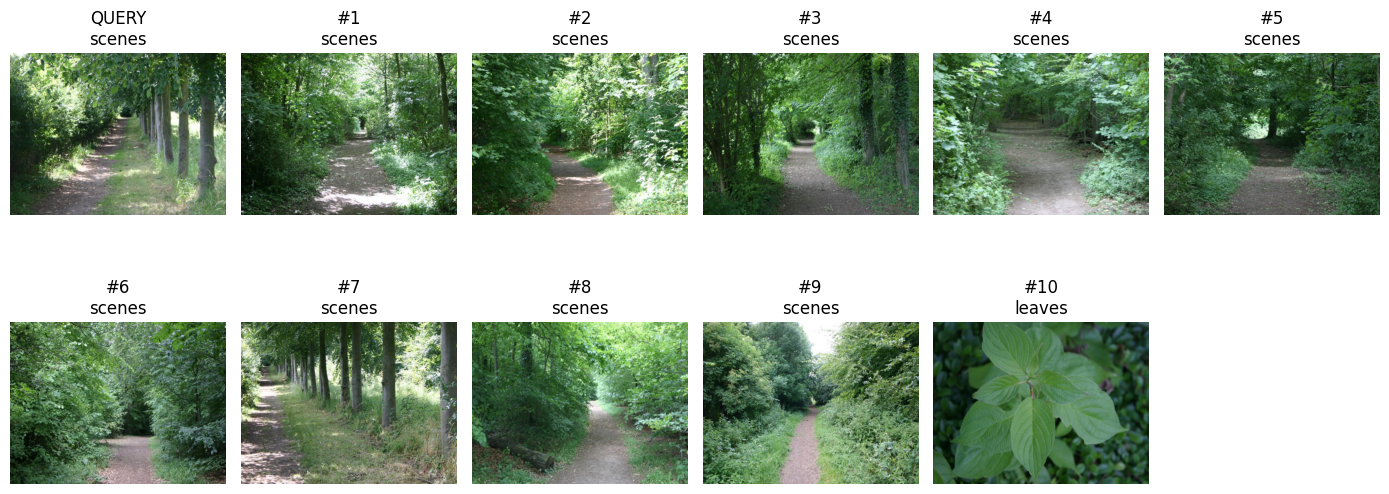

In [25]:
query_index = random.randrange(len(paths_sp))

topk_pca, _ = retrieve_topk_metric(query_index, X_sp_pca, paths_sp, labels_sp, k=10, metric="cosine")
show_retrieval(query_index, topk_pca, paths_sp, labels_sp, k=10)

In [26]:
results_pca = map_for_metric_with_label_index(
    X_sp_pca, labels_sp, label_to_indices_sp,
    metric="cosine",
    max_queries=None
)

print("\nOverall mAP (spatial 2x2 + PCA(95%) + cosine):", results_pca["mAP"])

per_class_pca = results_pca["per_class_AP"]
best5_pca = sorted(per_class_pca.items(), key=lambda kv: kv[1], reverse=True)[:5]
worst5_pca = sorted(per_class_pca.items(), key=lambda kv: kv[1])[:5]

print("\nTop 5 classes by AP (PCA):")
for c, v in best5_pca:
    print(f"  {c:20s} {v:.3f}")

print("\nBottom 5 classes by AP (PCA):")
for c, v in worst5_pca:
    print(f"  {c:20s} {v:.3f}")

Processed 200/4323 queries
Processed 400/4323 queries
Processed 600/4323 queries
Processed 800/4323 queries
Processed 1000/4323 queries
Processed 1200/4323 queries
Processed 1400/4323 queries
Processed 1600/4323 queries
Processed 1800/4323 queries
Processed 2000/4323 queries
Processed 2200/4323 queries
Processed 2400/4323 queries
Processed 2600/4323 queries
Processed 2800/4323 queries
Processed 3000/4323 queries
Processed 3200/4323 queries
Processed 3400/4323 queries
Processed 3600/4323 queries
Processed 3800/4323 queries
Processed 4000/4323 queries
Processed 4200/4323 queries

Overall mAP (spatial 2x2 + PCA(95%) + cosine): 0.24430836571924158

Top 5 classes by AP (PCA):
  clouds               0.461
  chimneys             0.363
  animals              0.350
  windows              0.314
  cars                 0.296

Bottom 5 classes by AP (PCA):
  benches_and_chairs   0.039
  birds                0.048
  miscellaneous        0.052
  signs                0.052
  buildings            0.054